<a href="https://colab.research.google.com/github/giacomomolinari/liar-fake-news-detector/blob/main/models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification Models

## Imports

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import transformers
import random

from datasets import load_dataset
from google.colab import drive
from pathlib import Path

from imblearn.under_sampling import RandomUnderSampler


from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, accuracy_score

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from datasets import Dataset, load_dataset
from torch.utils.data import DataLoader

## 1. Getting the data

The notebook assumes that the LIAR dataset is available on your Google Drive at the path defined below. You can download the dataset from [William Yang Wang's website](https://sites.cs.ucsb.edu/~william/data/liar_dataset.zip).

In [2]:
DATASET_PATH = Path("/content/drive/MyDrive/datasets/liar_dataset/")

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
columns= ["ID", "Label", "Statement", "Subjects", "Speaker", "SpeakerJob", "State", "Party",
          "HistBarelyTrue", "HistFalse", "HistHalfTrue", "HistMostTrue", "HistPantsFire", "Context"]

In [5]:
df_train = pd.read_csv(DATASET_PATH / "train.tsv", sep="\t", header=0, names=columns)
df_valid = pd.read_csv(DATASET_PATH / "valid.tsv", sep="\t", header=0, names=columns)
df_test = pd.read_csv(DATASET_PATH / "test.tsv", sep="\t", header=0, names=columns)

In [6]:
df_train.head()

,ID,Label,Statement,Subjects,Speaker,SpeakerJob,State,Party,HistBarelyTrue,HistFalse,HistHalfTrue,HistMostTrue,HistPantsFire,Context
0,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
1,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
2,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
3,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN
4,12465.json,true,The Chicago Bears have had more starting quart...,education,robin-vos,Wisconsin Assembly speaker,Wisconsin,republican,0.0,3.0,2.0,5.0,1.0,a an online opinion-piece


## 2. Preprocessing

### 2.1 Handling NaN values

As discussed in the eda notebook, only two columns have significant amounts of NaN values. I will remove these columns from the dataset to begin with.

In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10239 entries, 0 to 10238
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              10239 non-null  object 
 1   Label           10239 non-null  object 
 2   Statement       10239 non-null  object 
 3   Subjects        10237 non-null  object 
 4   Speaker         10237 non-null  object 
 5   SpeakerJob      7341 non-null   object 
 6   State           8029 non-null   object 
 7   Party           10237 non-null  object 
 8   HistBarelyTrue  10237 non-null  float64
 9   HistFalse       10237 non-null  float64
 10  HistHalfTrue    10237 non-null  float64
 11  HistMostTrue    10237 non-null  float64
 12  HistPantsFire   10237 non-null  float64
 13  Context         10137 non-null  object 
dtypes: float64(5), object(9)
memory usage: 1.1+ MB


In [8]:
df_train_clean = df_train.drop(["SpeakerJob", "State"], axis=1)
df_train_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10239 entries, 0 to 10238
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              10239 non-null  object 
 1   Label           10239 non-null  object 
 2   Statement       10239 non-null  object 
 3   Subjects        10237 non-null  object 
 4   Speaker         10237 non-null  object 
 5   Party           10237 non-null  object 
 6   HistBarelyTrue  10237 non-null  float64
 7   HistFalse       10237 non-null  float64
 8   HistHalfTrue    10237 non-null  float64
 9   HistMostTrue    10237 non-null  float64
 10  HistPantsFire   10237 non-null  float64
 11  Context         10137 non-null  object 
dtypes: float64(5), object(7)
memory usage: 960.0+ KB


For `NaN` values in the `Context` column, we will replace them with "no context provided."

In [9]:
df_train_clean.loc[df_train_clean["Context"].isna(), "Context"] = "no context provided."

In [10]:
df_train_clean[df_train_clean.isna().any(axis=1)]

,ID,Label,Statement,Subjects,Speaker,Party,HistBarelyTrue,HistFalse,HistHalfTrue,HistMostTrue,HistPantsFire,Context
2141,638.json,false,The fact is that although we have had a presid...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no context provided.
9374,1626.json,false,"Joe, I keep hearing you every morning talking ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no context provided.


Only two rows with NaN values remain, and these have all values NaN except for the statement. I will drop these for simplicity.

In [11]:
df_train_clean = df_train_clean.dropna()

Let's define a convenience function to apply the same changes to the validation and test dataframes

In [12]:
def clean_dataset(df):
  df_clean = df.drop(["SpeakerJob", "State"], axis=1)
  df_clean.loc[df_clean["Context"].isna(), "Context"] = "no context provided."
  df_clean = df_clean.dropna()
  return df_clean

In [13]:
df_valid_clean = clean_dataset(df_valid)

df_valid_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1283 entries, 0 to 1282
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              1283 non-null   object
 1   Label           1283 non-null   object
 2   Statement       1283 non-null   object
 3   Subjects        1283 non-null   object
 4   Speaker         1283 non-null   object
 5   Party           1283 non-null   object
 6   HistBarelyTrue  1283 non-null   int64 
 7   HistFalse       1283 non-null   int64 
 8   HistHalfTrue    1283 non-null   int64 
 9   HistMostTrue    1283 non-null   int64 
 10  HistPantsFire   1283 non-null   int64 
 11  Context         1283 non-null   object
dtypes: int64(5), object(7)
memory usage: 120.4+ KB


### 2.2 Selecting and Aggregating Features

As discussed in the EDA notebook, we will aggregate the `pants-fire` label with the `false` label to ensure the model is only learning about statement truthfulness, rather than learning possibly normative features like whether a lie is obvious, brazen, shocking or extravagant.

In [14]:
df_train_reduced = df_train_clean.copy()

In [15]:
df_train_reduced.loc[df_train_reduced["Label"] == "pants-fire", "Label"] = "false"

Then we will drop the "speaker history" features which contain the count of entries with each of the labels for the statement's speaker, and thus introduce data leak risks.

In [16]:
df_train_reduced = df_train_reduced.drop(["HistBarelyTrue", "HistFalse", "HistHalfTrue", "HistMostTrue", "HistPantsFire"], axis=1)

In [17]:
df_train_reduced.head()

,ID,Label,Statement,Subjects,Speaker,Party,Context
0,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,democrat,a floor speech.
1,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,democrat,Denver
2,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,none,a news release
3,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,democrat,an interview on CNN
4,12465.json,true,The Chicago Bears have had more starting quart...,education,robin-vos,republican,a an online opinion-piece


Again we define a utility function to perform this transformation.

In [18]:
def aggregate_and_drop(df):
  df_res = df.copy()
  df_res.loc[df_res["Label"] == "pants-fire", "Label"] = "false"
  df_res = df_res.drop(["HistBarelyTrue", "HistFalse", "HistHalfTrue", "HistMostTrue", "HistPantsFire"], axis=1)
  return df_res

In [19]:
df_valid_reduced = aggregate_and_drop(df_valid_clean)

df_valid_reduced.head()

,ID,Label,Statement,Subjects,Speaker,Party,Context
0,238.json,false,"When Obama was sworn into office, he DID NOT u...","obama-birth-certificate,religion",chain-email,none,no context provided.
1,7891.json,false,Says Having organizations parading as being so...,"campaign-finance,congress,taxes",earl-blumenauer,democrat,a U.S. Ways and Means hearing
2,8169.json,half-true,Says nearly half of Oregons children are poor.,poverty,jim-francesconi,none,an opinion article
3,929.json,half-true,On attacks by Republicans that various program...,"economy,stimulus",barack-obama,democrat,interview with CBS News
4,9416.json,false,Says when armed civilians stop mass shootings ...,guns,jim-rubens,republican,"in an interview at gun shop in Hudson, N.H."


### 2.3 Multi-hot encoding of Subject feature

The Subject feature is a list of tags, so we will encode it by creating a new feature for each (sufficiently common) tag, which is 1 iff the sample in question has that subject tag.

In [20]:
subject_set = set([])
subject_series = []
for subject in df_train_reduced["Subjects"]:
  if not isinstance(subject, str):
    print(subject)
  subject = subject.replace(", ", ",")
  split = subject.split(",")
  for s in split:
    if s not in subject_set:
      subject_set.add(s)
    subject_series.append(s)

In [21]:
subject_series = pd.Series(subject_series)
counts = subject_series.value_counts()
counts.count(), counts[counts > 100].count()

(np.int64(142), np.int64(59))

In [22]:
common_subjects = set(counts[counts > 100].index)

there are 100 subjects which appear over 40 times, while all others appear less than 40 times each. I will aggregate these infrequent subject tags into a new tag "other"

In [23]:
df_train_listsubject = df_train_reduced.copy()
df_train_listsubject["Subjects"] = (df_train_listsubject["Subjects"].apply(lambda x: x.replace(", ", ",").split(","))
  .apply(lambda x: [s if s in common_subjects else "other" for s in x])
  .apply(lambda x: list(set(x)))) # remove duplicates

In [24]:
df_train_listsubject.shape

(10237, 7)

In [25]:
df_exploded = df_train_listsubject.explode("Subjects")
df_exploded.head()

,ID,Label,Statement,Subjects,Speaker,Party,Context
0,10540.json,half-true,When did the decline of coal start? It started...,history,scott-surovell,democrat,a floor speech.
0,10540.json,half-true,When did the decline of coal start? It started...,job-accomplishments,scott-surovell,democrat,a floor speech.
0,10540.json,half-true,When did the decline of coal start? It started...,energy,scott-surovell,democrat,a floor speech.
1,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,democrat,Denver
2,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,none,a news release


In [26]:
one_hot = pd.get_dummies(df_exploded['Subjects'])

In [27]:
one_hot.shape

(21486, 60)

In [28]:
multi_hot = one_hot.groupby(one_hot.index).sum()
multi_hot.shape

(10237, 60)

In [29]:
df_train_multihot = df_train_reduced.merge(multi_hot, left_index=True, right_index=True).drop("Subjects", axis=1)
df_train_multihot.shape


(10237, 66)

To the original 7 features we added 101 subject features (100 for common subjects, 1 for "other"), and then removed the pre-existing "Subjects" feature, for a total of 107 features in the final dataset.

Again we define a utility function to more easily perform this transformation on the validation and test datasets.

In [30]:
def multi_hot_encode(df, subject_set):
  df_listsubject = df.copy()
  df_listsubject["Subjects"] = (df_listsubject["Subjects"].apply(lambda x: x.replace(", ", ",").split(","))
    .apply(lambda x: [s if s in subject_set else "other" for s in x])
    .apply(lambda x: list(set(x)))) # remove duplicates

  df_exploded = df_listsubject.explode("Subjects") # add new rows for each value in "Subjects" list, copying other fields

  one_hot = pd.get_dummies(df_exploded['Subjects']) # one-hot encode all possible "Subject" values
  multi_hot = one_hot.groupby(one_hot.index).sum()  # group back by index to restore origina number of columns
  return multi_hot.merge(df_listsubject.drop("Subjects", axis=1), left_index=True, right_index=True)

In [31]:
df_valid_reduced.shape

(1283, 7)

In [32]:
df_valid_multihot = multi_hot_encode(df_valid_reduced, common_subjects)
df_valid_multihot.shape

(1283, 66)

### 2.4 Statement Length

I will remove all statements with over 40 words from the dataset. As shown in the EDA notebook, this adds up to about 100 statements, some of which are hundreds of words long, well above the dataset mode of 15. By removing these long statements we reduce the amount of padding needed to ensure all sequences processed by the RNN have the same length, which can improve performance.

In [33]:
df_train_preprocessed = df_train_multihot.copy()
df_train_preprocessed["StatementLength"] = df_train_preprocessed["Statement"].apply(lambda x: len(x.split(" ")))
df_train_preprocessed[["Statement", "StatementLength"]].head()

,Statement,StatementLength
0,When did the decline of coal start? It started...,24
1,"Hillary Clinton agrees with John McCain ""by vo...",19
2,Health care reform legislation is likely to ma...,12
3,The economic turnaround started at the end of ...,10
4,The Chicago Bears have had more starting quart...,27


In [34]:
df_train_preprocessed.shape

(10237, 67)

In [35]:
df_train_preprocessed = df_train_preprocessed[df_train_preprocessed["StatementLength"] < 40]
df_train_preprocessed.shape

(10111, 67)

As usual we define a utility function for this transformation.

In [36]:
def drop_statements_longer_than(df, maxLength):
  df_res = df.copy()
  df_res["StatementLength"] = df_res["Statement"].apply(lambda x: len(x.split(" ")))
  df_res = df_res[df_res["StatementLength"] < maxLength]
  return df_res

In [37]:
df_valid_preprocessed = drop_statements_longer_than(df_valid_multihot, 40)
df_valid_preprocessed.shape

(1269, 67)

## 3. Baseline Model 1: Metadata-only classifier

As a first baseline let's build a model that tries to classify statements based only on the available metadata: the name of the speaker, their political affiliation, and the topics touched on by the statement. I will also include the statement length, which is a derived piece of metadata and may potentially be helpful.

### 3.1 Preparing the data

We need a little bit more preprocessing before the metadata is ready to be used by a ML classifier. In particular, the remaining categorical features (`Speaker` and `Party`) must be converted to numerical ones, and the numerical feature `StatementLength` must be normalized.

#### 3.1.1 Normalizing StatementLength

In [38]:
subjects_set_list = list(common_subjects.union({"other"}))
meta_features = ["Speaker", "Party", "StatementLength"] + subjects_set_list

X_train_meta = df_train_preprocessed[meta_features]
y_train_meta = df_train_preprocessed["Label"]

X_train_meta.head()

,Speaker,Party,StatementLength,public-health,immigration,income,campaign-finance,iraq,market-regulation,women,...,military,corrections-and-updates,stimulus,economy,polls,poverty,ethics,pundits,voting-record,government-efficiency
0,scott-surovell,democrat,24,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,barack-obama,democrat,19,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,blog-posting,none,12,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,charlie-crist,democrat,10,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,robin-vos,republican,27,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [39]:
min_max_scaler = MinMaxScaler(feature_range=(0, 1))
X_train_meta[["StatementLength"]] = min_max_scaler.fit_transform(X_train_meta[["StatementLength"]])
X_train_meta.head()

/tmp/ipykernel_491/501206241.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_meta[["StatementLength"]] = min_max_scaler.fit_transform(X_train_meta[["StatementLength"]])


,Speaker,Party,StatementLength,public-health,immigration,income,campaign-finance,iraq,market-regulation,women,...,military,corrections-and-updates,stimulus,economy,polls,poverty,ethics,pundits,voting-record,government-efficiency
0,scott-surovell,democrat,0.594595,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,barack-obama,democrat,0.459459,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,blog-posting,none,0.270270,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,charlie-crist,democrat,0.216216,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,robin-vos,republican,0.675676,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [40]:
statement_length_normalized = X_train_meta["StatementLength"]
statement_length_normalized.describe()

,StatementLength
count,10111.000000
mean,0.421080
std,0.194204
min,0.000000
25%,0.270270
50%,0.405405
75%,0.540541
max,1.000000


#### 3.1.2. Encoding Speaker

In [41]:
speaker_counts = X_train_meta["Speaker"].value_counts()
speaker_counts

,count
Speaker,
barack-obama,483
donald-trump,269
hillary-clinton,233
mitt-romney,175
john-mccain,148
...,...
jeff-clemens,1
scott-lingamfelter,1
clay-dafoe,1


Clearly there are too many speakers for one-hot encoding. But for many of these speakers, they appear too infrequently for the model to actually be able to learn much about them. So let's look at how many speakers appear frequently.

In [42]:
speaker_counts[speaker_counts>50].count()

np.int64(20)

Interestingly, only 65 speakers appear over 20 times. So we will aggregate all other speakers to a new value "other", and then one-hot encode this feature to generate 66 more feature (removing the existing `Speaker` feature)

In [43]:
common_speakers = set(speaker_counts[speaker_counts>50].index)

X_train_speaker_encoded = X_train_meta.copy()
X_train_speaker_encoded["Speaker"] = X_train_meta["Speaker"].apply(lambda x: x if x in common_speakers else "other")
X_train_speaker_encoded = pd.get_dummies(X_train_speaker_encoded, columns=["Speaker"])
X_train_speaker_encoded.head()

,Party,StatementLength,public-health,immigration,income,campaign-finance,iraq,market-regulation,women,energy,...,Speaker_john-mccain,Speaker_marco-rubio,Speaker_mitt-romney,Speaker_newt-gingrich,Speaker_other,Speaker_paul-ryan,Speaker_rick-perry,Speaker_rick-scott,Speaker_scott-walker,Speaker_ted-cruz
0,democrat,0.594595,0,0,0,0,0,0,0,1,...,False,False,False,False,True,False,False,False,False,False
1,democrat,0.459459,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,none,0.270270,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,democrat,0.216216,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,republican,0.675676,0,0,0,0,0,0,0,0,...,False,False,False,False,True,False,False,False,False,False


#### 3.1.3 Encoding Party

We can one-hot encode the `Party` feature in a similar way.

In [44]:
party_counts = X_train_meta["Party"].value_counts()
party_counts[party_counts>50]

,count
Party,
republican,4451
democrat,3281
none,1726
organization,216
independent,146
newsmaker,55


In [45]:
party_counts[party_counts>50]

,count
Party,
republican,4451
democrat,3281
none,1726
organization,216
independent,146
newsmaker,55


Again it makes sense to aggregate parties that are too infrequent to be actually learned by the model.

In [46]:
common_parties = set(party_counts[party_counts>50].index)
X_train_party_encoded = X_train_speaker_encoded.copy()

X_train_party_encoded["Party"] = X_train_speaker_encoded["Party"].apply(lambda x: x if x in common_parties else "other")
X_train_party_encoded = pd.get_dummies(X_train_party_encoded, columns=["Party"])
X_train_party_encoded.head()

,StatementLength,public-health,immigration,income,campaign-finance,iraq,market-regulation,women,energy,message-machine,...,Speaker_rick-scott,Speaker_scott-walker,Speaker_ted-cruz,Party_democrat,Party_independent,Party_newsmaker,Party_none,Party_organization,Party_other,Party_republican
0,0.594595,0,0,0,0,0,0,0,1,0,...,False,False,False,True,False,False,False,False,False,False
1,0.459459,0,0,0,0,0,0,0,0,0,...,False,False,False,True,False,False,False,False,False,False
2,0.270270,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,True,False,False,False
3,0.216216,0,0,0,0,0,0,0,0,0,...,False,False,False,True,False,False,False,False,False,False
4,0.675676,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,True


In [47]:
X_train_party_encoded.shape

(10111, 89)

Finally we convert the boolean values to integers for numerical processing and consistency.

In [48]:
X_train_meta = X_train_party_encoded.copy()

X_statement_length = X_train_meta["StatementLength"].copy()
X_train_meta = X_train_meta.map(lambda x: int(x))
X_train_meta["StatementLength"] = X_statement_length

X_train_meta.head()

,StatementLength,public-health,immigration,income,campaign-finance,iraq,market-regulation,women,energy,message-machine,...,Speaker_rick-scott,Speaker_scott-walker,Speaker_ted-cruz,Party_democrat,Party_independent,Party_newsmaker,Party_none,Party_organization,Party_other,Party_republican
0,0.594595,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
1,0.459459,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,0.270270,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0.216216,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0.675676,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


As before we define a function that performs all these transformations on a dataset.

In [49]:
def meta_preprocessing(df):
  df_res = df.copy()

  min_max_scaler = MinMaxScaler(feature_range=(0, 1))
  df_res["StatementLength"] = min_max_scaler.fit_transform(df[["StatementLength"]])

  df_res["Speaker"] = df_res["Speaker"].apply(lambda x: x if x in common_speakers else "other")
  df_res = pd.get_dummies(df_res, columns=["Speaker"])

  df_res["Party"] = df_res["Party"].apply(lambda x: x if x in common_parties else "other")
  df_res = pd.get_dummies(df_res, columns=["Party"])

  df_statement_length = df_res["StatementLength"].copy()
  df_res = df_res.map(lambda x: int(x))
  df_res["StatementLength"] = df_statement_length

  return df_res

In [50]:
X_valid_meta = df_valid_preprocessed[meta_features]
y_valid_meta = df_valid_preprocessed["Label"]

X_valid_meta.head()

,Speaker,Party,StatementLength,public-health,immigration,income,campaign-finance,iraq,market-regulation,women,...,military,corrections-and-updates,stimulus,economy,polls,poverty,ethics,pundits,voting-record,government-efficiency
0,chain-email,none,26,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,earl-blumenauer,democrat,32,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,jim-francesconi,none,8,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,barack-obama,democrat,33,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
4,jim-rubens,republican,22,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [51]:
X_valid_meta = meta_preprocessing(X_valid_meta)
X_valid_meta.head()

,StatementLength,public-health,immigration,income,campaign-finance,iraq,market-regulation,women,energy,message-machine,...,Speaker_rick-scott,Speaker_scott-walker,Speaker_ted-cruz,Party_democrat,Party_independent,Party_newsmaker,Party_none,Party_organization,Party_other,Party_republican
0,0.638889,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,0.805556,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,0.138889,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0.833333,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0.527778,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


This has one fewer column than our preprocessed training dataset, so there is probably a categorical feature that never appears in the validation set but which appears in the training set.

In [52]:
X_valid_meta.columns.difference(X_train_meta.columns)
X_train_meta.columns.difference(X_valid_meta.columns)


Index([], dtype='object')

It looks like a speaker that appears frequently in training data never appears in the validation data. We can fix this by just adding this column to the validation dataset and filling it with zeros

In [53]:
X_valid_meta["Speaker_rush-limbaugh"] = 0
X_valid_meta.shape

(1269, 90)

In [54]:
## Reorder validation dataframe so that features are in same order as training one
## (necessary for scikit learn's predictors)
X_valid_meta = X_valid_meta[X_train_meta.columns]
X_valid_meta.shape

(1269, 89)

### 3.2 Selecting and training models

#### 3.2.1 Defining the evaluation measures

We will evaluate our models by first converting the labels into integers and then calculating the MAE. This preserves the intuitive ordering that is intrinsic in these truthfulness labels. For example, if a statement is almost-true, it seems better to have classified it as true than to have classified it as false (although one could plausibly wish to specify just how much better that is, I will for simplicity just take this to be specified by the MAE metric).

I will also evaluate our model using the usual accuracy metric, for comparison and more interpretable results.

In [55]:
label_to_int = {"false": 0, "barely-true": 1, "half-true": 2, "mostly-true": 3, "true": 4}

y_train_meta_int = y_train_meta.apply(lambda x: label_to_int[x])
y_valid_meta_int = y_valid_meta.apply(lambda x: label_to_int[x])

In [56]:
scoring_rule = "accuracy"
scoring_rule_ordinal = "neg_mean_absolute_error"

#### 3.2.2 Simple Baseline Classifiers

As a sanity check, it's useful to define a **Majority Class Classifier**. This is a classifier which just predicts the most frequent class regardless of input. Its performance on the task provides a performance floor which our models should be able to clear if they have learned anything at all

In [57]:
y_mode = y_train_meta_int.mode()[0]
y_mode

np.int64(0)

In [58]:
def majority_class_classifier(X, y):
  return np.ones((len(X), 1))* y.mode()[0]

In [59]:
mean_absolute_error(y_valid_meta_int, majority_class_classifier(X_valid_meta, y_train_meta_int))

1.6800630417651694

In [60]:
accuracy_score(y_valid_meta_int, majority_class_classifier(X_valid_meta, y_train_meta_int))

0.2978723404255319

As expected this has an accuracy of around 30%, as around 27% of statements in the training dataset are false.

#### 3.2.3 Tree classifier

We use a simple tree classifier, limiting depth to avoid it catastrophically overfitting the training set.

In [61]:
tree_model = DecisionTreeClassifier(random_state=42, max_depth=15)

tree_model

DecisionTreeClassifier(max_depth=15, random_state=42)

In [62]:
tree_model_cv = -cross_val_score(tree_model, X_train_meta, y_train_meta_int, scoring=scoring_rule_ordinal, cv=10)

tree_model_cv.mean()

np.float64(1.5292267273430995)

In [63]:
tree_model.fit(X_train_meta, y_train_meta_int)

DecisionTreeClassifier(max_depth=15, random_state=42)

In [64]:
mean_absolute_error(y_valid_meta_int, tree_model.predict(X_valid_meta))

1.425531914893617

In [65]:
accuracy_score(y_valid_meta_int, tree_model.predict(X_valid_meta))

0.31048069345941687

This does noticeably better than the majority class predictor in both MAE and accuracy, but it still has far from a great performance. To check that it's in fact not overfitting, let's look at the accuracy on training set

In [66]:
accuracy_score(y_train_meta_int, tree_model.predict(X_train_meta))

0.3949164276530511

Slightly better, but no sign of strong overfit.

In [67]:
y_pred = tree_model.predict(X_valid_meta)
pd.Series(y_pred).value_counts()

,count
0,761
3,258
2,171
1,51
4,28


We can see here that the model almost degenerates to the majority classifier. The model is not really learning from the features - rather it is learning that False is the most probable label, and hedging with some barely-true or half-true predictions.

#### 3.2.4 Random forest classifier

Let's try a slightly more powerful model, with slightly more fine-tuning.

In [68]:
forest_model = RandomForestClassifier(random_state=42)

forest_model_cv = cross_val_score(forest_model, X_train_meta, y_train_meta_int, scoring=scoring_rule, cv=5)

forest_model_cv.mean()

np.float64(0.2538819891719998)

In [69]:
forest_model.fit(X_train_meta, y_train_meta_int)

RandomForestClassifier(random_state=42)

In [70]:
mean_absolute_error(y_valid_meta_int, forest_model.predict(X_valid_meta))

1.4609929078014185

In [71]:
accuracy_score(y_valid_meta_int, forest_model.predict(X_valid_meta))

0.26713947990543735

In [72]:
accuracy_score(y_train_meta_int, forest_model.predict(X_train_meta))

0.8858668776579962

Much like for the tree classifier, the unconstrained version of RandomForest heavily overfits the training data. So let's look for some regularization hyperparameter values that improve this.

In [73]:
parameter_grid = [
    {
        "max_depth": [10, 15, 20, 25, 30],
        "max_features": [10, 20, 30, 40, 50]
    }
]

In [74]:
# forest_cls = RandomForestClassifier(random_state=42)

# grid_search = GridSearchCV(forest_cls, parameter_grid, cv=5, scoring=scoring_rule)
# grid_search.fit(X_train_meta, y_train_meta_int)
# grid_search.best_params_

In [75]:
forest_model = RandomForestClassifier(random_state=42, max_depth=10, max_features=30)


forest_model.fit(X_train_meta, y_train_meta_int)

RandomForestClassifier(max_depth=10, max_features=30, random_state=42)

In [76]:
mean_absolute_error(y_valid_meta_int, forest_model.predict(X_valid_meta))

1.408983451536643

In [77]:
accuracy_score(y_valid_meta_int, forest_model.predict(X_valid_meta))

0.3262411347517731

In [78]:
accuracy_score(y_train_meta_int, forest_model.predict(X_train_meta))

0.38512511126495896

In [79]:
pd.Series(y_pred).value_counts()

,count
0,761
3,258
2,171
1,51
4,28


Similar problem as the tree model, the RandomForest almost degenerates to a majority classifier!

#### 3.2.5 Reducing the feature space

In [80]:
X_train_meta_reduced = X_train_meta.drop(common_subjects, axis=1)
X_train_meta_reduced = X_train_meta_reduced.drop(["Party_" + x for x in common_parties.union(set(['other']))], axis=1)
X_train_meta_reduced.head()

X_valid_meta_reduced = X_valid_meta.drop(common_subjects, axis=1)
X_valid_meta_reduced = X_valid_meta_reduced.drop(["Party_" + x for x in common_parties.union(set(['other']))], axis=1)
X_valid_meta_reduced.head()

,StatementLength,other,Speaker_barack-obama,Speaker_bernie-s,Speaker_blog-posting,Speaker_chain-email,Speaker_charlie-crist,Speaker_chris-christie,Speaker_donald-trump,Speaker_facebook-posts,...,Speaker_john-mccain,Speaker_marco-rubio,Speaker_mitt-romney,Speaker_newt-gingrich,Speaker_other,Speaker_paul-ryan,Speaker_rick-perry,Speaker_rick-scott,Speaker_scott-walker,Speaker_ted-cruz
0,0.638889,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.805556,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0.138889,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0.833333,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0.527778,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [81]:
tree_model = DecisionTreeClassifier(random_state=42, max_depth=11)

tree_model_cv = -cross_val_score(tree_model, X_train_meta_reduced, y_train_meta_int, scoring=scoring_rule_ordinal, cv=10)

tree_model_cv.mean()

np.float64(1.6343573458752143)

In [82]:
tree_model.fit(X_train_meta_reduced, y_train_meta_int)

DecisionTreeClassifier(max_depth=11, random_state=42)

In [83]:
mean_absolute_error(y_valid_meta_int, tree_model.predict(X_valid_meta_reduced)), accuracy_score(y_valid_meta_int, tree_model.predict(X_valid_meta_reduced))

(1.5366430260047281, 0.30023640661938533)

In [84]:
accuracy_score(y_train_meta_int, tree_model.predict(X_train_meta_reduced))

0.311146276332707

In [85]:
y_pred = tree_model.predict(X_valid_meta_reduced)
pd.Series(y_pred).value_counts()

,count
0,988
2,220
4,35
3,16
1,10


Still overfitting unless we let it deteriorate to majority classifier.

#### 3.2.6 Support Vector Classifier

Let's try using a support vector classifier, as SVCs tend to work well in high-dimensional spaces.

In [86]:
svm_clf = SVC(random_state=42)

svm_clf_cv = -cross_val_score(svm_clf, X_train_meta, y_train_meta_int, scoring=scoring_rule_ordinal, cv=5)

svm_clf_cv.mean()

np.float64(1.4844204115578856)

This is not much better than previous examples.

In [87]:
svm_clf.fit(X_train_meta, y_train_meta_int)

SVC(random_state=42)

In [88]:
pd.Series([mean_absolute_error(y_valid_meta_int, svm_clf.predict(X_valid_meta)),
 accuracy_score(y_valid_meta_int, svm_clf.predict(X_valid_meta)),
 accuracy_score(y_train_meta_int, svm_clf.predict(X_train_meta))], index=["MAE", "AccuracyValid", "AccuracyTest"])

,0
MAE,1.456265
AccuracyValid,0.314421
AccuracyTest,0.411928


In [89]:
pd.Series(svm_clf.predict(X_valid_meta)).value_counts()

,count
0,832
3,190
2,176
4,47
1,24


We observe the same sort of deterioration to majority classifier.

#### 3.2.7 Rebalancing class frequencies

In [90]:
UnderSampler = RandomUnderSampler(random_state=42, replacement=True)

X_under, y_under = UnderSampler.fit_resample(X_train_meta, y_train_meta_int)

X_under_valid, y_under_valid = UnderSampler.fit_resample(X_valid_meta, y_valid_meta_int)

y_under.value_counts(), y_under_valid.value_counts()

(Label
 0    1631
 1    1631
 2    1631
 3    1631
 4    1631
 Name: count, dtype: int64,
 Label
 0    167
 1    167
 2    167
 3    167
 4    167
 Name: count, dtype: int64)

After undersampling all 5 classes have the exact same frequency in the dataset. Hence our baseline majority classifier will have 20% accuracy.

In [91]:
accuracy_score(y_under_valid, majority_class_classifier(X_under_valid, y_under))

0.2

In [92]:
X_under

,StatementLength,public-health,immigration,income,campaign-finance,iraq,market-regulation,women,energy,message-machine,...,Speaker_rick-scott,Speaker_scott-walker,Speaker_ted-cruz,Party_democrat,Party_independent,Party_newsmaker,Party_none,Party_organization,Party_other,Party_republican
2954,0.270270,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4577,0.216216,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3959,0.351351,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3793,0.405405,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
5961,0.540541,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7345,0.270270,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
9344,0.351351,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4259,0.270270,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
8995,0.216216,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0


In [93]:
X_under_reduced = X_under.drop(common_subjects, axis=1)
X_under_reduced = X_under.drop(["Party_" + x for x in common_parties.union(set(['other']))], axis=1)
X_under_reduced.head()

X_under_valid_reduced = X_under_valid.drop(common_subjects, axis=1)
X_under_valid_reduced = X_under_valid.drop(["Party_" + x for x in common_parties.union(set(['other']))], axis=1)
X_under_valid_reduced.head()

,StatementLength,public-health,immigration,income,campaign-finance,iraq,market-regulation,women,energy,message-machine,...,Speaker_john-mccain,Speaker_marco-rubio,Speaker_mitt-romney,Speaker_newt-gingrich,Speaker_other,Speaker_paul-ryan,Speaker_rick-perry,Speaker_rick-scott,Speaker_scott-walker,Speaker_ted-cruz
329,0.333333,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1185,0.388889,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
913,0.555556,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
337,0.694444,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
216,0.472222,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [94]:
svm_clf = SVC(random_state=42, C=10)

svm_clf_cv = -cross_val_score(svm_clf, X_under_reduced, y_under, scoring=scoring_rule_ordinal, cv=5)

svm_clf_cv.mean()

np.float64(1.2469650521152666)

In [95]:
svm_clf.fit(X_under, y_under)

SVC(C=10, random_state=42)

In [96]:
pd.Series([mean_absolute_error(y_under, svm_clf.predict(X_under)),
 accuracy_score(y_under_valid, svm_clf.predict(X_under_valid)),
 accuracy_score(y_under, svm_clf.predict(X_under))], index=["MAE", "AccuracyValid", "AccuracyTest"])

,0
MAE,0.647823
AccuracyValid,0.269461
AccuracyTest,0.679215


In [97]:
pd.Series(svm_clf.predict(X_under_valid)).value_counts()

,count
1,218
0,204
4,149
3,132
2,132


In [98]:
tree_model = DecisionTreeClassifier(random_state=42, max_depth=15)

tree_model_cv = -cross_val_score(tree_model, X_under, y_under, scoring=scoring_rule_ordinal, cv=10)

tree_model_cv.mean()

np.float64(1.446593287621797)

In [99]:
tree_model.fit(X_under, y_under)

DecisionTreeClassifier(max_depth=15, random_state=42)

In [100]:
pd.Series([mean_absolute_error(y_under, tree_model.predict(X_under)),
 accuracy_score(y_under_valid, tree_model.predict(X_under_valid)),
 accuracy_score(y_under, tree_model.predict(X_under))], index=["MAE", "AccuracyValid", "AccuracyTest"])

,0
MAE,1.323728
AccuracyValid,0.226347
AccuracyTest,0.380258


In [101]:
forest_model = RandomForestClassifier(random_state=42, max_depth=10, n_estimators=1000)

forest_model.fit(X_under, y_under)

RandomForestClassifier(max_depth=10, n_estimators=1000, random_state=42)

In [102]:
forest_model_cv = -cross_val_score(forest_model, X_under, y_under, scoring=scoring_rule_ordinal, cv=10)

forest_model_cv.mean()

np.float64(1.222800433056658)

In [103]:
pd.Series([mean_absolute_error(y_under, forest_model.predict(X_under)),
 accuracy_score(y_under_valid, forest_model.predict(X_under_valid)),
 accuracy_score(y_under, forest_model.predict(X_under))], index=["MAE", "AccuracyValid", "AccuracyTest"])

,0
MAE,0.960025
AccuracyValid,0.275449
AccuracyTest,0.515880


This model reaches over 27% in validation accuracy, which is actually noticeably better than the majority model now that all labels have been rebalanced by undersampling. After rebalancing, the baseline majority classifier only has 20% accuracy, so this is a 7% improvement. Furthermore, the accuracy achieved by this model is comparable to that achieved in [William Wang's paper](https://https://aclanthology.org/P17-2067/) which introduced the LIAR dataset, when evaluating models that use metadata only.

The model is still overfitting, but validation accuracy seems to decrease too when introducing more regularization.

In [104]:
pd.Series(forest_model.predict(X_under_valid)).value_counts()

,count
0,240
3,208
1,181
2,105
4,101


We can see that, while the model is slightly skewed towards predicting falsehood still, the distribution of predictions is far more balanced.

## 4. Baseline Model 2: Text-only classifier

### 4.1 Preparing the data

In [38]:
statements_train = list(df_train_preprocessed["Statement"].apply(lambda x: x.lower()))
statements_valid = list(df_valid_preprocessed["Statement"].apply(lambda x: x.lower()))

statements_train[:3]

['when did the decline of coal start? it started when natural gas took off that started to begin in (president george w.) bushs administration.',
 'hillary clinton agrees with john mccain "by voting to give george bush the benefit of the doubt on iran."',
 'health care reform legislation is likely to mandate free sex change surgeries.']

### 4.2 Tokenizer

I will use a pre-trained WordPiece tokenizer extracted from a BERT model.

In [39]:
bert_tokenizer = transformers.AutoTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [40]:
bert_encoding = bert_tokenizer(statements_train, padding=True, truncation=True, max_length=80, return_tensors="pt")


We can plot the length (in tokens) of each sequence by plotting the sum of the attention masks for each token.

<Axes: ylabel='Frequency'>

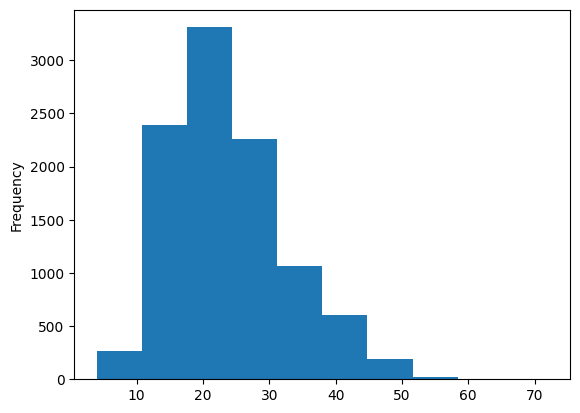

In [41]:
pd.Series([attention_mask.sum() for attention_mask in bert_encoding["attention_mask"]]).apply(lambda x: int(x)).plot.hist()

### 4.3 Building the Datasets and DataLoaders

First we convert our Pandas dataframes into Dataset objects

In [42]:
label_to_int = {"false": 0, "barely-true": 1, "half-true": 2, "mostly-true": 3, "true": 4}


df_train_textonly = df_train_preprocessed[["Statement", "Label"]].copy()
df_train_textonly["Label"] = df_train_preprocessed["Label"].apply(lambda x: label_to_int[x])
df_train_textonly["Statement"] = df_train_preprocessed["Statement"].apply(lambda x: x.lower())


df_valid_textonly = df_valid_preprocessed[["Statement", "Label"]].copy()
df_valid_textonly["Label"] = df_valid_preprocessed["Label"].apply(lambda x: label_to_int[x])
df_valid_textonly["Statement"] = df_valid_preprocessed["Statement"].apply(lambda x: x.lower())

df_train_textonly.head()

,Statement,Label
0,when did the decline of coal start? it started...,2
1,"hillary clinton agrees with john mccain ""by vo...",3
2,health care reform legislation is likely to ma...,0
3,the economic turnaround started at the end of ...,2
4,the chicago bears have had more starting quart...,4


In [43]:
ds_train = Dataset.from_pandas(df_train_textonly)
ds_valid = Dataset.from_pandas(df_valid_textonly)

ds_train

Dataset({
    features: ['Statement', 'Label', '__index_level_0__'],
    num_rows: 10111
})

Then we can use DataLoaders to tokenize the statements as they are passed to the model.

In [44]:
def collate_fn(batch, tokenizer = bert_tokenizer):
  statements = [x["Statement"] for x in batch]
  labels = [[x["Label"]] for x in batch]

  encodings = tokenizer(statements, padding=True, truncation=True, max_length=80, return_tensors="pt")

  labels = torch.tensor(labels, dtype=torch.int64)

  return encodings, labels

In [45]:
batch_size = 128 # increase to 256 if GPU allows it

text_train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
text_valid_loader = DataLoader(ds_valid, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

### 4.4 Building the Model

#### 4.4.1 Untrained Model (Training from scratch)

Let's define a class for our model

In [46]:
class LieDetector_TextOnly(nn.Module):
  def __init__(self, vocab_size, n_layers=2, embed_dim = 128, hidden_dim=64, pad_id=0, dropout=0.2):
    super().__init__()

    self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
    self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=n_layers, batch_first=True, dropout=dropout)

    self.output = nn.Linear(hidden_dim, 5) # output class logits

  def forward(self, encodings):
    embeddings = self.embedding(encodings["input_ids"])
    _outputs, hidden_states = self.gru(embeddings)
    return self.output(hidden_states[-1])

Then let's define training and evaluation functions, using the GPU for training.

In [47]:
if torch.cuda.is_available():
    device="cuda"
elif torch.backends.mps.is_available:
    device="mps"
else:
    device="cpu"

device

'cuda'

In [48]:
# Evaluation function (not using torchmetrics)
def evaluate(model, data_loader, criterion):
  model.eval()
  total_loss = 0
  with torch.no_grad():
    for X_batch, y_batch in data_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)

      y_batch = y_batch.squeeze(1)

      loss = criterion(y_pred, y_batch)
      total_loss += loss.item()
  return total_loss/len(data_loader)

In [49]:
# Evaluation function (not using torchmetrics)
def evaluate_as_regression(model, data_loader, criterion):
  model.eval()
  total_loss = 0
  with torch.no_grad():
    for X_batch, y_batch in data_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch).softmax(dim=-1).float().to(device)

      y_batch = target_idx_to_vector(y_batch, 5)
      y_batch = y_batch.squeeze(1).to(device)

      loss = criterion(y_pred, y_batch)
      total_loss += loss.item()
  return total_loss/len(data_loader)

In [50]:
# General training function
def train(model, optimizer, criterion, train_loader, valid_loader, n_epochs):
  for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      y_batch = y_batch.squeeze(1)

      loss = criterion(y_pred, y_batch)
      total_loss += loss.item()

      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
    mean_loss = total_loss / len(train_loader)
    eval_loss = evaluate(model, valid_loader, criterion)
    print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {mean_loss:.4f}, Validation Loss: {eval_loss:.4f}")

In [51]:
def target_idx_to_vector(target_idxs, length):
  target_vector = torch.zeros(len(target_idxs), length)#
  for i, target_idx in enumerate(target_idxs):
    target_vector[i, target_idx] = 1
  return target_vector

In [52]:
# Train by converting the logits to probabilities and the targets to indicator vectors, then measuring divergence
# More computationally expensive than training with logits only
def train_as_regression(model, optimizer, criterion, train_loader, valid_loader, n_epochs):
  for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch).softmax(dim=-1).float().to(device)
      y_batch = target_idx_to_vector(y_batch, 5)
      y_batch = y_batch.squeeze(1).to(device)

      """ DEBUG:
      print("Shapes:")
      print("y_pred: ", y_pred.shape)
      print("y_batch: ", y_batch.shape)

      print("Types:")
      print("y_pred: ", y_pred.dtype)
      print("y_batch: ", y_batch.dtype)

      print("Tensors:")
      print("y_pred: ", y_pred)
      print("y_batch: ", y_batch)

      print(loss.requires_grad)

      END DEBUG"""

      loss = criterion(y_pred, y_batch)
      total_loss += loss.item()

      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
    mean_loss = total_loss / len(train_loader)
    eval_loss = evaluate_as_regression(model, valid_loader, criterion)
    print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {mean_loss:.4f}, Validation Loss: {eval_loss:.4f}")

In [53]:
torch.manual_seed(42)

In [54]:
model = LieDetector_TextOnly(vocab_size=bert_tokenizer.vocab_size, pad_id=bert_tokenizer.pad_token_id).to(device)


We compute class frequencies on the non-rebalanced dataset to use the weights in scoring.

In [55]:
class_counts = np.array(df_train_textonly.groupby("Label").count().values.flatten())
class_counts

array([2804, 1631, 2083, 1937, 1656])

In [56]:
class_weights = 1.0/class_counts                                  # weight inversely proportional to number of occurrences
class_weights = torch.tensor(class_weights/ class_weights.sum())  # normalize

class_weights = class_weights.float().to(device)
class_weights

tensor([0.1388, 0.2386, 0.1868, 0.2009, 0.2350], device='cuda:0')

In [57]:
learning_rate = 0.0005
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [58]:
train(model,  optimizer=optimizer, criterion=criterion, train_loader = text_train_loader, valid_loader = text_valid_loader, n_epochs=25)

Epoch 1/25, Train Loss: 1.6101, Validation Loss: 1.6078
Epoch 2/25, Train Loss: 1.6088, Validation Loss: 1.6063
Epoch 3/25, Train Loss: 1.6079, Validation Loss: 1.6057
Epoch 4/25, Train Loss: 1.6059, Validation Loss: 1.6106
Epoch 5/25, Train Loss: 1.6015, Validation Loss: 1.6078
Epoch 6/25, Train Loss: 1.5893, Validation Loss: 1.6215
Epoch 7/25, Train Loss: 1.5625, Validation Loss: 1.6274
Epoch 8/25, Train Loss: 1.5213, Validation Loss: 1.6391
Epoch 9/25, Train Loss: 1.4722, Validation Loss: 1.6932
Epoch 10/25, Train Loss: 1.4158, Validation Loss: 1.6916
Epoch 11/25, Train Loss: 1.3541, Validation Loss: 1.7589
Epoch 12/25, Train Loss: 1.2909, Validation Loss: 1.8491
Epoch 13/25, Train Loss: 1.2094, Validation Loss: 1.9032
Epoch 14/25, Train Loss: 1.1248, Validation Loss: 2.0367
Epoch 15/25, Train Loss: 1.0606, Validation Loss: 2.0876
Epoch 16/25, Train Loss: 0.9943, Validation Loss: 2.1403
Epoch 17/25, Train Loss: 0.9357, Validation Loss: 2.2642
Epoch 18/25, Train Loss: 0.8610, Validat

The model seems to be overfitting to an extreme degree, where the validation performance actually gets worse and worse as the model fits to the training dataset.



Let's write a simple utility function to give us an intuitive sense of how the model performs on a few validation statements

In [93]:
def sample_validation_results(model, validation_set, sample_size):
  valid_length = len(validation_set)
  statement_list = list(validation_set["Statement"])
  label_list = list(validation_set["Label"])
  sample = random.sample(range(0, valid_length), sample_size)

  df = pd.DataFrame(columns=["Statement", "Label", "Prediction"])

  for entry_idx in sample:
    statement = statement_list[entry_idx]
    label = label_list[entry_idx]

    tokenized_statement = bert_tokenizer(statement, padding=True, truncation=True, max_length=80, return_tensors="pt")

    model.eval()
    with torch.no_grad():
      prediction = model(tokenized_statement.to(device)).argmax(dim=-1).item()
      df.loc[len(df)] = [statement, label, prediction]
  return df



In [94]:
sample_validation_results(model, ds_valid, 10)

,Statement,Label,Prediction
0,says president dwight eisenhower moved 1.5 mil...,2,0
1,the u.s. army had a training program that put ...,1,1
2,40% of americans know someone who has been kil...,3,2
3,"under president ronald reagan, illegal immigra...",0,3
4,he voted twice for a budget resolution that in...,2,0
5,most americans are ready to put it [marijuana ...,4,4
6,members of congress and their families and sta...,0,3
7,"in 2013 we had the largest, the best, private ...",3,4
8,"over the past eight years, black youth unemplo...",1,3
9,says there have been 50 million abortions sinc...,4,3


This clearly shows that the model is performing very poorly. The likely reason for this poor performance is that the model just doesn't have enough information available in the dataset to learn reasonably informative/meaningful embeddings of the tokens, which in turn are necessary for determining whether the statements are true or false. A better approach would be to reuse the pre-trained embedding layer of an existing model, which can represent tokens into reasonably informative embeddings, and then focus our model training on determining degree of truthfulness from these embeddings.

## 5. Main Model: Text and metadata classifier